# Insurance Fraud Detection Using Machine Learning

## Project Overview

Insurance companies face major financial losses due to fraudulent insurance claims. Fraud occurs when individuals attempt to obtain benefits they are not entitled to by submitting false or exaggerated claims.

**Objective:** Build a machine learning model that can predict whether an insurance claim is fraudulent or legitimate.

## Business Requirements

The system should:
- Detect fraudulent insurance claims
- Improve claim processing speed
- Reduce financial losses
- Support decision-making for insurance investigators

## Social & Business Impact

Benefits include:
- Reduced financial loss for insurance companies
- Faster fraud detection
- Improved transparency in claim processing
- Protection for honest policyholders

**Team Members:**
- Vidish Kumar (Team Lead)
- Somya Kushwah
- Gaurangi Sharma
- Kritika Gupta

---

## Machine Learning Lifecycle

This project follows a comprehensive ML workflow divided into 6 Epics:

1. **Epic 1:** Problem Understanding
2. **Epic 2:** Data Collection & Preparation
3. **Epic 3:** Exploratory Data Analysis (EDA)
4. **Epic 4:** Model Building (7 algorithms)
5. **Epic 5:** Performance Testing & Comparison
6. **Epic 6:** Model Deployment (Streamlit App)

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


## 2. EPIC 2: Data Collection & Preparation

### 2.1 Load Dataset

A dataset containing insurance claim records is collected from Kaggle.

The dataset includes features like:
- **Customer information:** age, sex, education level, occupation
- **Policy details:** policy state, deductible, premium amount
- **Incident information:** type, severity, location, time
- **Claim amounts:** injury, property, vehicle claims
- **Fraud label:** Target variable (Y/N)

In [2]:
df = pd.read_csv('insurance_claims.csv')

print(f"✓ Dataset loaded successfully!")
print(f"Dataset Shape: {df.shape}")
print(f"\nNumber of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
df.head()

✓ Dataset loaded successfully!
Dataset Shape: (1000, 40)

Number of rows: 1000
Number of columns: 40


,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


## 3. EPIC 3: Exploratory Data Analysis (EDA)

EDA helps understand the dataset and discover patterns in fraud claims.

This section includes:
- **Visual Analysis:** Histograms, bar charts, distribution plots
- **Multivariate Analysis:** Correlation heatmaps, feature relationships
- **Statistical Analysis:** Descriptive statistics, distributions

### 3.1 Dataset Information

In [3]:
print("Dataset Information:")
print("=" * 70)
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   object 
 4   policy_state                 1000 non-null   object 
 5   policy_csl                   1000 non-null   object 
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   object 
 11  insured_education_level      1000 non-null   object 
 12  insured_occupation           1000 non-null   object 
 13

In [4]:
df.describe()

,months_as_customer,age,policy_number,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,capital-gains,capital-loss,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_year,_c39
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,0.0
mean,203.954000,38.948000,546238.648000,1136.000000,1256.406150,1.101000e+06,501214.488000,25126.100000,-26793.700000,11.644000,1.83900,0.992000,1.487000,52761.94000,7433.420000,7399.570000,37928.950000,2005.103000,NaN
std,115.113174,9.140287,257063.005276,611.864673,244.167395,2.297407e+06,71701.610941,27872.187708,28104.096686,6.951373,1.01888,0.820127,1.111335,26401.53319,4880.951853,4824.726179,18886.252893,6.015861,NaN
min,0.000000,19.000000,100804.000000,500.000000,433.330000,-1.000000e+06,430104.000000,0.000000,-111100.000000,0.000000,1.00000,0.000000,0.000000,100.00000,0.000000,0.000000,70.000000,1995.000000,NaN
25%,115.750000,32.000000,335980.250000,500.000000,1089.607500,0.000000e+00,448404.500000,0.000000,-51500.000000,6.000000,1.00000,0.000000,1.000000,41812.50000,4295.000000,4445.000000,30292.500000,2000.000000,NaN
50%,199.500000,38.000000,533135.000000,1000.000000,1257.200000,0.000000e+00,466445.500000,0.000000,-23250.000000,12.000000,1.00000,1.000000,1.000000,58055.00000,6775.000000,6750.000000,42100.000000,2005.000000,NaN
75%,276.250000,44.000000,759099.750000,2000.000000,1415.695000,0.000000e+00,603251.000000,51025.000000,0.000000,17.000000,3.00000,2.000000,2.000000,70592.50000,11305.000000,10885.000000,50822.500000,2010.000000,NaN
max,479.000000,64.000000,999435.000000,2000.000000,2047.590000,1.000000e+07,620962.000000,100500.000000,0.000000,23.000000,4.00000,2.000000,3.000000,114920.00000,21450.000000,23670.000000,79560.000000,2015.000000,NaN


### 3.2 Missing Values Analysis

Missing Values:
                       Missing Count  Percentage
_c39                            1000       100.0
authorities_contacted             91         9.1


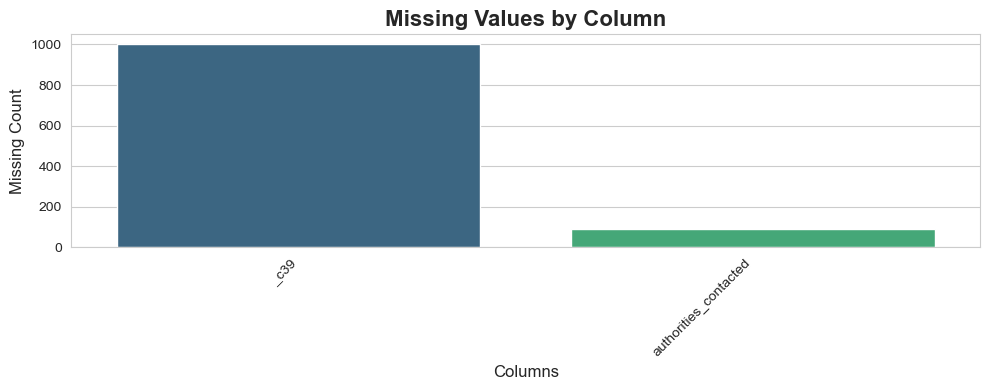

In [5]:
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Percentage': missing_percentage
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

print("Missing Values:")
print(missing_df)

if len(missing_df) > 0:
    plt.figure(figsize=(10, 4))
    sns.barplot(x=missing_df.index, y=missing_df['Missing Count'], palette='viridis')
    plt.title('Missing Values by Column', fontsize=16, fontweight='bold')
    plt.xlabel('Columns', fontsize=12)
    plt.ylabel('Missing Count', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("\n✓ No missing values found!")

### 3.3 Target Variable Distribution

Fraud Reported Distribution:
fraud_reported
N    753
Y    247
Name: count, dtype: int64

Fraud Percentage: 24.70%


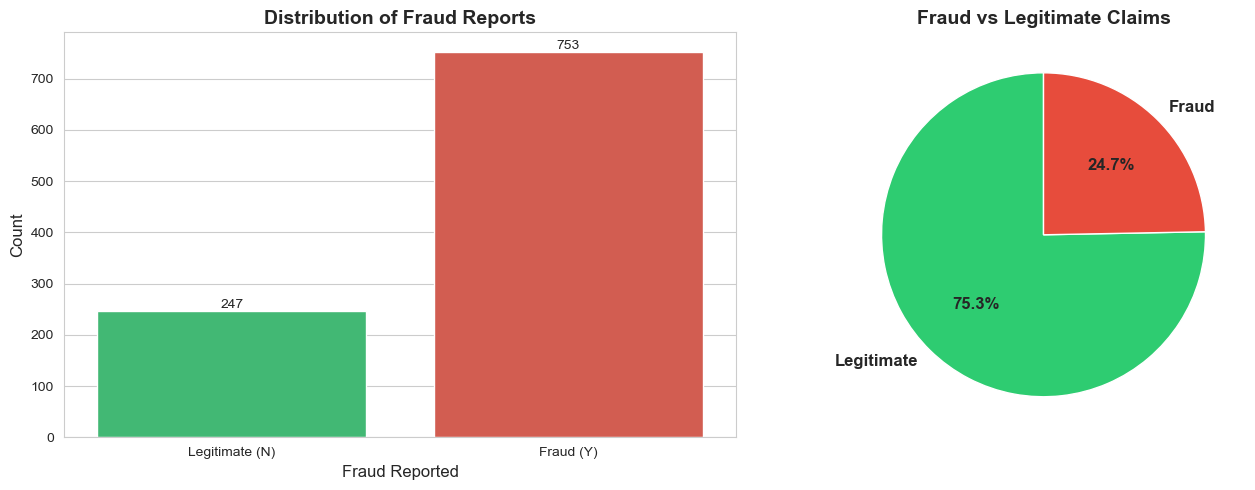

In [6]:
print("Fraud Reported Distribution:")
print(df['fraud_reported'].value_counts())
print(f"\nFraud Percentage: {(df['fraud_reported'].value_counts()['Y'] / len(df)) * 100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x='fraud_reported', palette=['#2ecc71', '#e74c3c'], ax=axes[0])
axes[0].set_title('Distribution of Fraud Reports', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Fraud Reported', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_xticklabels(['Legitimate (N)', 'Fraud (Y)'])

for container in axes[0].containers:
    axes[0].bar_label(container)

fraud_counts = df['fraud_reported'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[1].pie(fraud_counts.values, labels=['Legitimate', 'Fraud'], autopct='%1.1f%%', 
            colors=colors, startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('Fraud vs Legitimate Claims', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### 3.4 Demographic Analysis

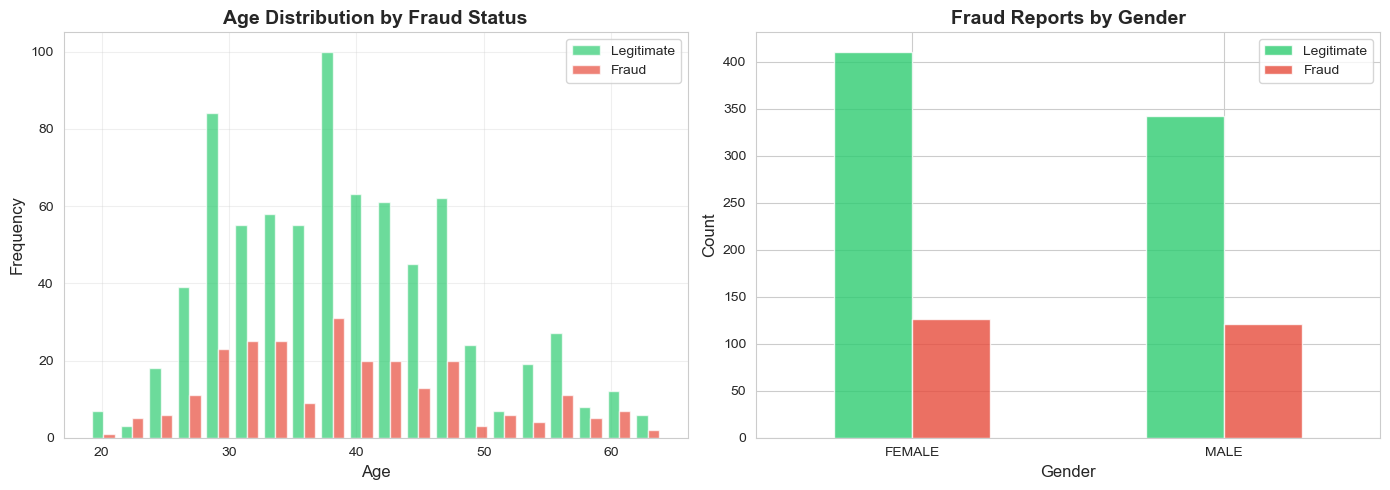

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist([df[df['fraud_reported']=='N']['age'], df[df['fraud_reported']=='Y']['age']], 
             bins=20, label=['Legitimate', 'Fraud'], color=['#2ecc71', '#e74c3c'], alpha=0.7)
axes[0].set_title('Age Distribution by Fraud Status', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].legend()
axes[0].grid(alpha=0.3)

fraud_by_gender = pd.crosstab(df['insured_sex'], df['fraud_reported'])
fraud_by_gender.plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'], alpha=0.8)
axes[1].set_title('Fraud Reports by Gender', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Gender', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].legend(['Legitimate', 'Fraud'])
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

### 3.5 Incident Analysis

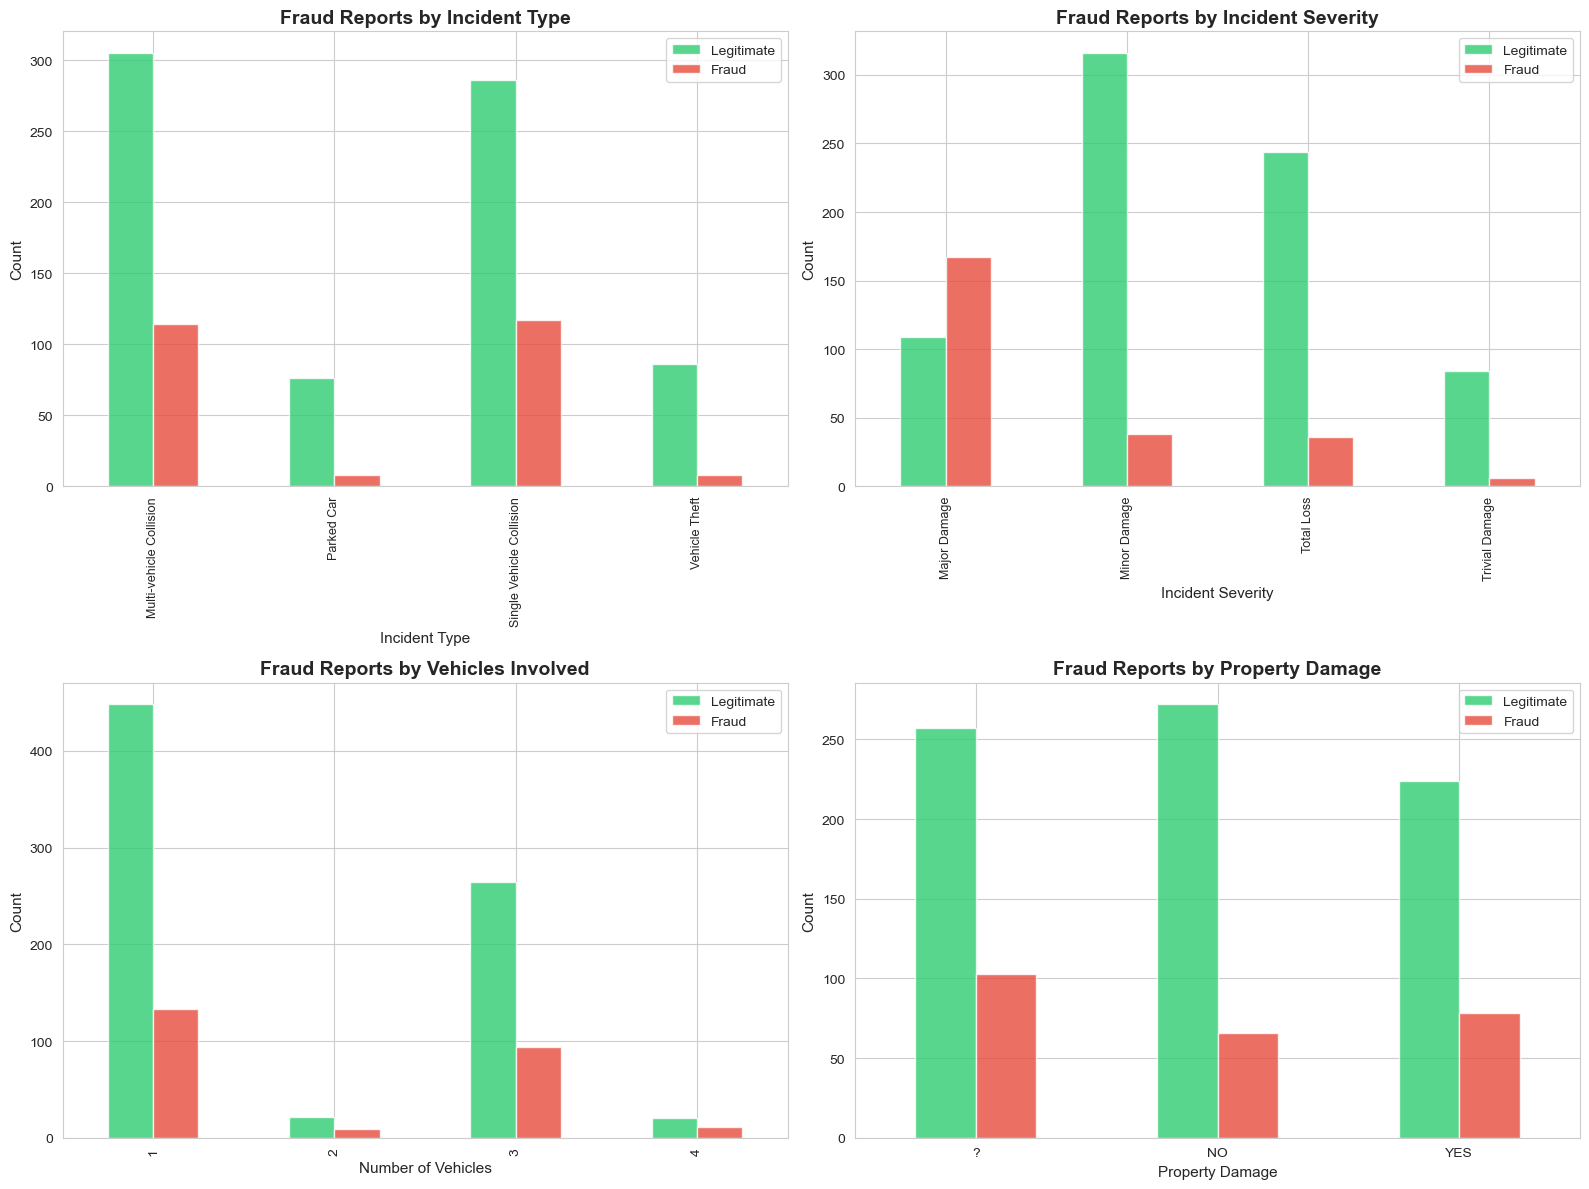

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

pd.crosstab(df['incident_type'], df['fraud_reported']).plot(kind='bar', ax=axes[0, 0], 
                                                             color=['#2ecc71', '#e74c3c'], alpha=0.8)
axes[0, 0].set_title('Fraud Reports by Incident Type', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Incident Type', fontsize=11)
axes[0, 0].set_ylabel('Count', fontsize=11)
axes[0, 0].legend(['Legitimate', 'Fraud'])
axes[0, 0].tick_params(axis='x', labelsize=9)

pd.crosstab(df['incident_severity'], df['fraud_reported']).plot(kind='bar', ax=axes[0, 1], 
                                                                  color=['#2ecc71', '#e74c3c'], alpha=0.8)
axes[0, 1].set_title('Fraud Reports by Incident Severity', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Incident Severity', fontsize=11)
axes[0, 1].set_ylabel('Count', fontsize=11)
axes[0, 1].legend(['Legitimate', 'Fraud'])
axes[0, 1].tick_params(axis='x', labelsize=9)

pd.crosstab(df['number_of_vehicles_involved'], df['fraud_reported']).plot(kind='bar', ax=axes[1, 0], 
                                                                            color=['#2ecc71', '#e74c3c'], alpha=0.8)
axes[1, 0].set_title('Fraud Reports by Vehicles Involved', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Number of Vehicles', fontsize=11)
axes[1, 0].set_ylabel('Count', fontsize=11)
axes[1, 0].legend(['Legitimate', 'Fraud'])

pd.crosstab(df['property_damage'], df['fraud_reported']).plot(kind='bar', ax=axes[1, 1], 
                                                                color=['#2ecc71', '#e74c3c'], alpha=0.8)
axes[1, 1].set_title('Fraud Reports by Property Damage', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Property Damage', fontsize=11)
axes[1, 1].set_ylabel('Count', fontsize=11)
axes[1, 1].legend(['Legitimate', 'Fraud'])
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

### 3.6 Claim Amount Analysis

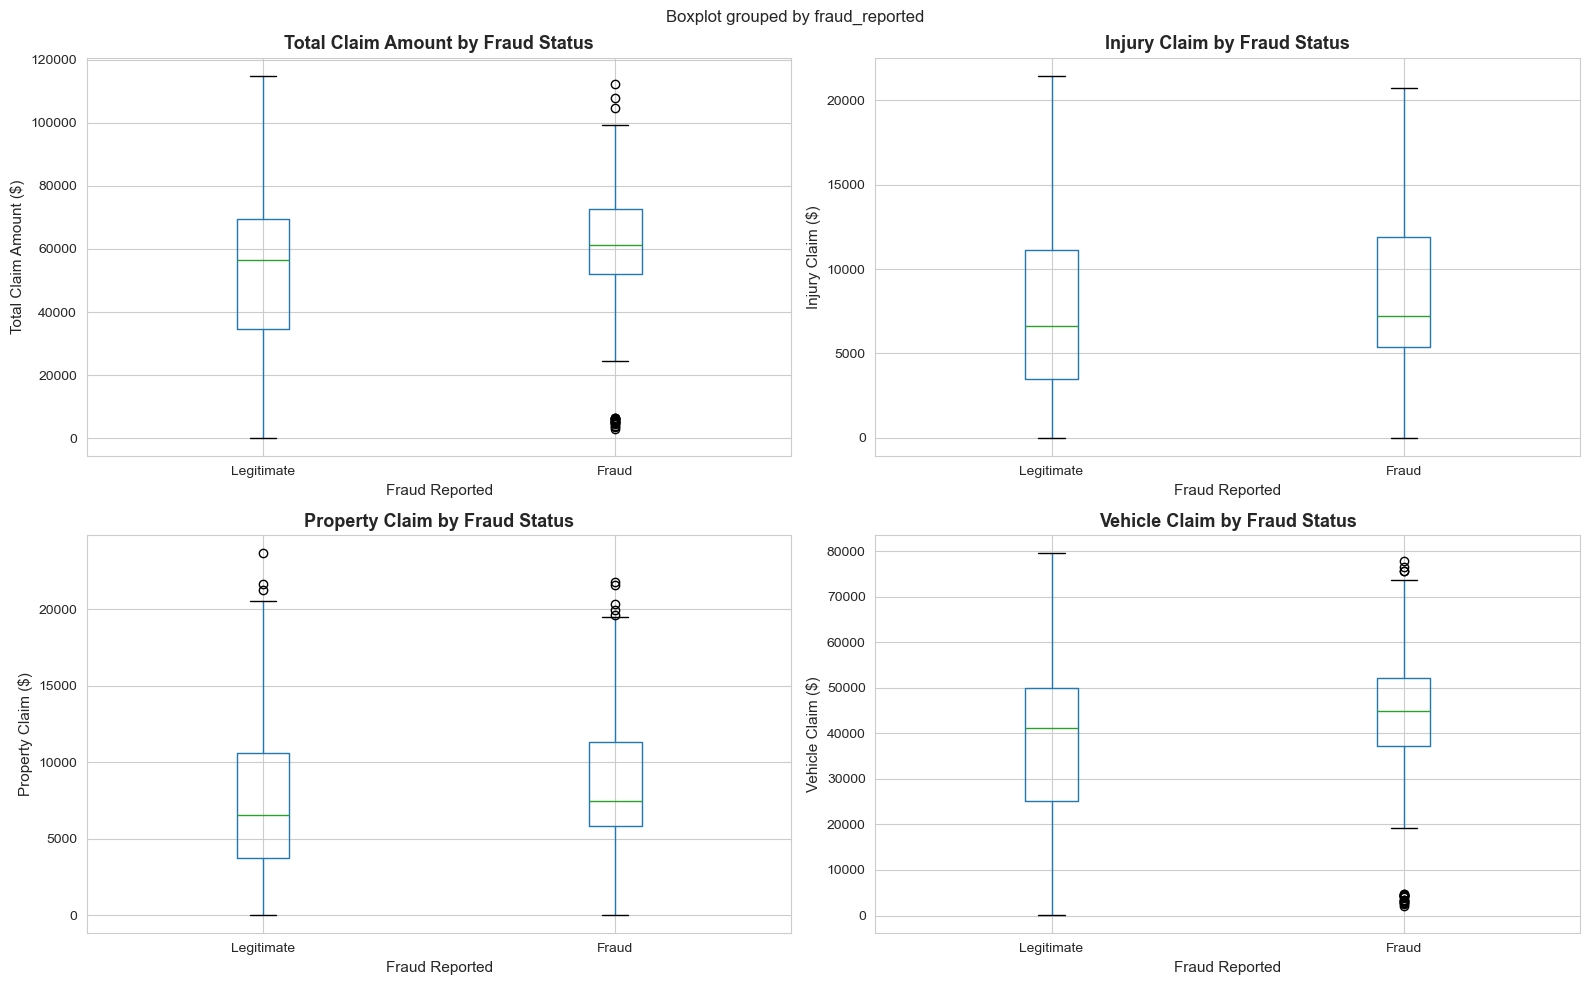

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

df.boxplot(column='total_claim_amount', by='fraud_reported', ax=axes[0, 0])
axes[0, 0].set_title('Total Claim Amount by Fraud Status', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Fraud Reported', fontsize=11)
axes[0, 0].set_ylabel('Total Claim Amount ($)', fontsize=11)
plt.sca(axes[0, 0])
plt.xticks([1, 2], ['Legitimate', 'Fraud'])

df.boxplot(column='injury_claim', by='fraud_reported', ax=axes[0, 1])
axes[0, 1].set_title('Injury Claim by Fraud Status', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Fraud Reported', fontsize=11)
axes[0, 1].set_ylabel('Injury Claim ($)', fontsize=11)
plt.sca(axes[0, 1])
plt.xticks([1, 2], ['Legitimate', 'Fraud'])

df.boxplot(column='property_claim', by='fraud_reported', ax=axes[1, 0])
axes[1, 0].set_title('Property Claim by Fraud Status', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Fraud Reported', fontsize=11)
axes[1, 0].set_ylabel('Property Claim ($)', fontsize=11)
plt.sca(axes[1, 0])
plt.xticks([1, 2], ['Legitimate', 'Fraud'])

df.boxplot(column='vehicle_claim', by='fraud_reported', ax=axes[1, 1])
axes[1, 1].set_title('Vehicle Claim by Fraud Status', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Fraud Reported', fontsize=11)
axes[1, 1].set_ylabel('Vehicle Claim ($)', fontsize=11)
plt.sca(axes[1, 1])
plt.xticks([1, 2], ['Legitimate', 'Fraud'])

plt.tight_layout()
plt.show()

for ax in axes.flat:
    ax.get_figure().suptitle('')

### 3.7 Correlation Analysis

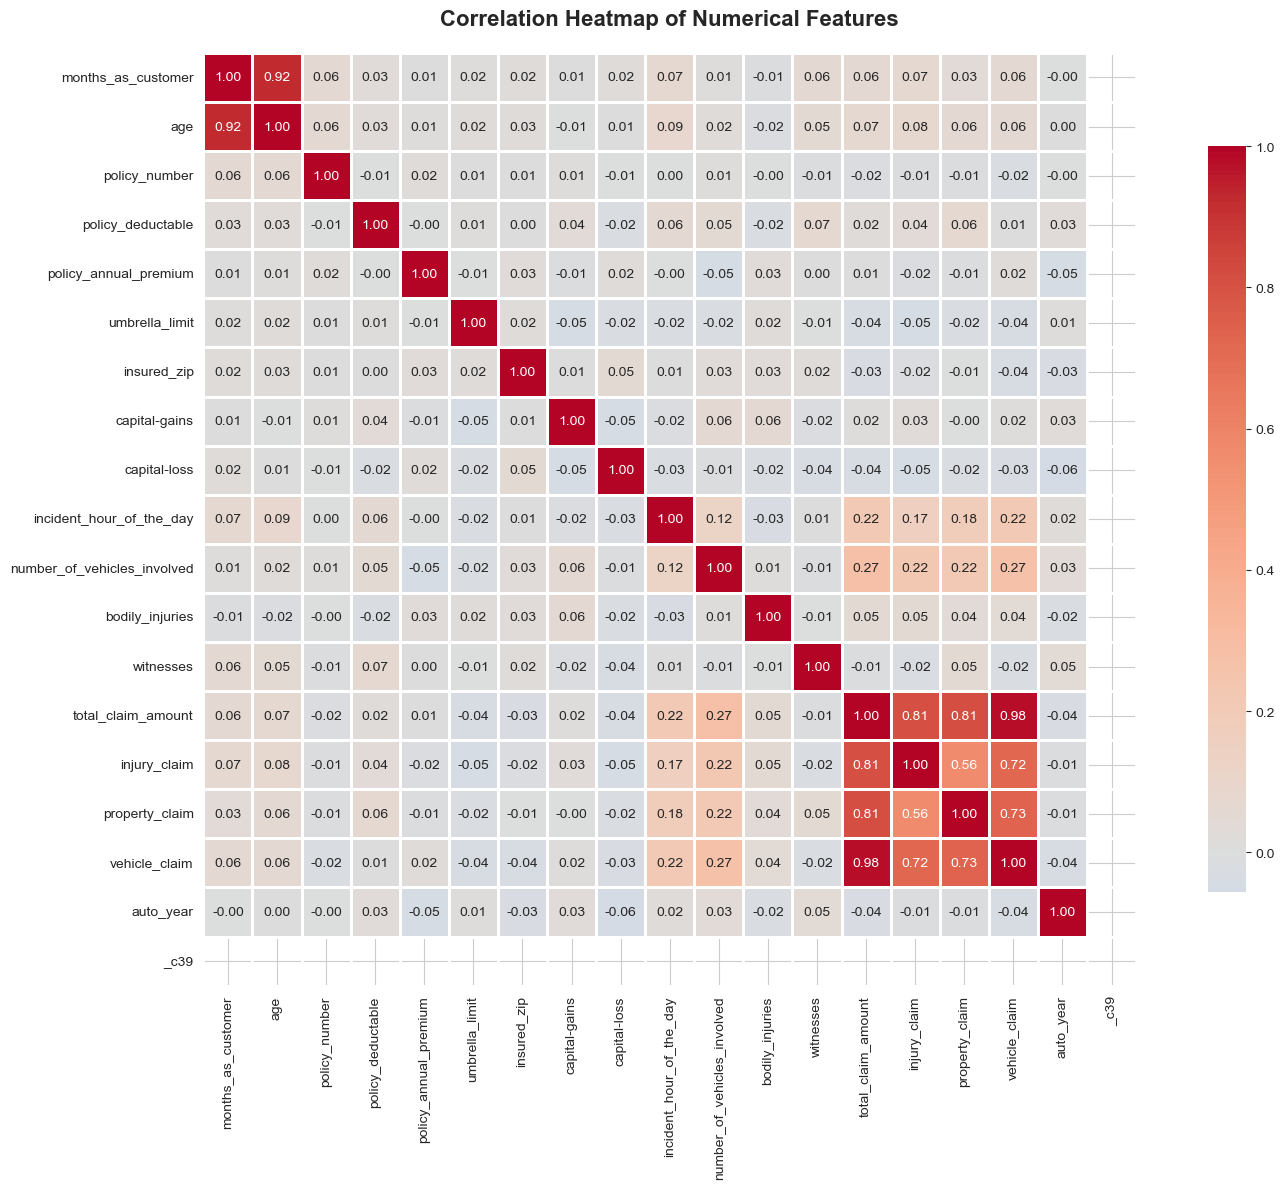

In [10]:
numerical_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap of Numerical Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

In [11]:
print("Starting Data Preprocessing...")
print("=" * 70)

df_clean = df.copy()

print(f"\nRows before preprocessing: {len(df_clean)}")

df_clean.replace('?', np.nan, inplace=True)

missing_counts = df_clean.isnull().sum()
print("\nColumns with missing values:")
print(missing_counts[missing_counts > 0])

threshold_missing = len(df_clean) * 0.5
cols_to_drop = missing_counts[missing_counts > threshold_missing].index

if len(cols_to_drop) > 0:
    print(f"\nDropping columns with >50% missing values: {list(cols_to_drop)}")
    df_clean.drop(columns=cols_to_drop, inplace=True)

for col in df_clean.columns:
    if df_clean[col].isnull().sum() > 0:
        if df_clean[col].dtype in ['int64', 'float64']:
            df_clean[col].fillna(df_clean[col].median(), inplace=True)
        else:
            df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

print(f"\nRows after handling missing values: {len(df_clean)}")

duplicates = df_clean.duplicated().sum()
print(f"\nDuplicate rows found: {duplicates}")

df_clean.drop_duplicates(inplace=True)

print(f"Rows after removing duplicates: {len(df_clean)}")

print("\n🔧 Date Feature Engineering...")
df_clean['incident_date'] = pd.to_datetime(df_clean['incident_date'], errors='coerce')
df_clean['incident_date'].fillna(df_clean['incident_date'].mode()[0], inplace=True)
df_clean['incident_month'] = df_clean['incident_date'].dt.month
df_clean['incident_day'] = df_clean['incident_date'].dt.day
df_clean['incident_weekday'] = df_clean['incident_date'].dt.weekday
df_clean.drop('incident_date', axis=1, inplace=True)
print("✓ Created date features: incident_month, incident_day, incident_weekday")

print("\n🔧 Feature Engineering...")
df_clean['claim_ratio'] = df_clean['total_claim_amount'] / (df_clean['policy_annual_premium'] + 1)
df_clean['claim_per_vehicle'] = df_clean['total_claim_amount'] / (df_clean['number_of_vehicles_involved'] + 1)
df_clean['claim_per_injury'] = df_clean['injury_claim'] / (df_clean['bodily_injuries'] + 1)
df_clean['coverage_ratio'] = df_clean['total_claim_amount'] / (df_clean['umbrella_limit'] + 1)
df_clean['injury_severity_score'] = df_clean['bodily_injuries'] * df_clean['injury_claim']
df_clean['night_incident'] = (df_clean['incident_hour_of_the_day'] < 6).astype(int)
print("✓ Created 6 engineered features: claim_ratio, claim_per_vehicle, claim_per_injury, coverage_ratio, injury_severity_score, night_incident")

df_clean['fraud_reported'] = df_clean['fraud_reported'].map({'Y':1,'N':0})

print("\n✓ Target variable converted to binary (0 = Legitimate, 1 = Fraud)")

X = df_clean.drop(columns=['fraud_reported']).copy()
y = df_clean['fraud_reported'].copy()

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")

Starting Data Preprocessing...

Rows before preprocessing: 1000

Columns with missing values:
collision_type              178
authorities_contacted        91
property_damage             360
police_report_available     343
_c39                       1000
dtype: int64

Dropping columns with >50% missing values: ['_c39']

Rows after handling missing values: 1000

Duplicate rows found: 0
Rows after removing duplicates: 1000

🔧 Date Feature Engineering...
✓ Created date features: incident_month, incident_day, incident_weekday

🔧 Feature Engineering...
✓ Created 6 engineered features: claim_ratio, claim_per_vehicle, claim_per_injury, coverage_ratio, injury_severity_score, night_incident

✓ Target variable converted to binary (0 = Legitimate, 1 = Fraud)

Features shape: (1000, 46)
Target shape: (1000,)


In [12]:
print("\nEncoding categorical variables...")

categorical_columns = X.select_dtypes(include=['object']).columns

print(f"\nCategorical columns ({len(categorical_columns)}):")
print(list(categorical_columns))

label_encoders = {}

for col in categorical_columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

print("\n✓ Categorical variables encoded successfully")
print("Feature types after encoding:")
print(X.dtypes.value_counts())


Encoding categorical variables...

Categorical columns (19):
['policy_bind_date', 'policy_state', 'policy_csl', 'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_hobbies', 'insured_relationship', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state', 'incident_city', 'incident_location', 'property_damage', 'police_report_available', 'auto_make', 'auto_model']

✓ Categorical variables encoded successfully
Feature types after encoding:
int64      38
float64     5
int32       3
Name: count, dtype: int64


In [13]:
print("\n🔎 Feature Selection with SelectKBest...")
selector = SelectKBest(score_func=f_classif, k=25)
X_selected = selector.fit_transform(X, y)
selected_feature_mask = selector.get_support()
selected_feature_names = X.columns[selected_feature_mask]

print(f"Selected feature shape: {X_selected.shape}")
print("Top selected features:")
print(list(selected_feature_names))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)

print("\n✓ Features scaled using StandardScaler")
print(f"Scaled data shape: {X_scaled.shape}")


🔎 Feature Selection with SelectKBest...
Selected feature shape: (1000, 25)
Top selected features:
['policy_number', 'policy_state', 'policy_csl', 'umbrella_limit', 'insured_sex', 'insured_hobbies', 'incident_type', 'incident_severity', 'authorities_contacted', 'incident_state', 'incident_city', 'number_of_vehicles_involved', 'bodily_injuries', 'witnesses', 'total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim', 'incident_month', 'incident_day', 'claim_ratio', 'claim_per_vehicle', 'claim_per_injury', 'coverage_ratio', 'injury_severity_score']

✓ Features scaled using StandardScaler
Scaled data shape: (1000, 25)


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nData Split:")
print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

print(f"\nTraining set fraud distribution:")
print(y_train.value_counts())
print(f"\nTesting set fraud distribution:")
print(y_test.value_counts())


Data Split:
Training set size: 800
Testing set size: 200

Training set fraud distribution:
fraud_reported
0    602
1    198
Name: count, dtype: int64

Testing set fraud distribution:
fraud_reported
0    151
1     49
Name: count, dtype: int64


## 5. EPIC 4: Model Building

In this phase, multiple machine learning models are trained using the prepared dataset.

### 5.1 Handle Class Imbalance with SMOTE

Before training models, we'll balance the dataset using SMOTE (Synthetic Minority Over-sampling Technique) to improve fraud detection.

In [15]:
print("Class distribution before SMOTE:")
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("\n✓ SMOTE applied successfully")
print("Class distribution after SMOTE:")
print(pd.Series(y_train_resampled).value_counts())
print(f"\nResampled training set size: {X_train_resampled.shape[0]}")

Class distribution before SMOTE:
fraud_reported
0    602
1    198
Name: count, dtype: int64

✓ SMOTE applied successfully
Class distribution after SMOTE:
fraud_reported
0    602
1    602
Name: count, dtype: int64

Resampled training set size: 1204


  File "c:\Users\vidis\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\vidis\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\vidis\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\vidis\anaconda3\Lib\subprocess.

In [16]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=5000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Naïve Bayes': GaussianNB(),
    'Support Vector Machine': SVC(random_state=42, probability=True)
}

print("Training Base Models with SMOTE...")
print("=" * 70)

results = []
trained_models = {}
predictions = {}

for model_name, model in models.items():
    print(f"\n🔄 Training {model_name}...")
    
    model.fit(X_train_resampled, y_train_resampled)
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    try:
        if hasattr(model, 'predict_proba'):
            y_prob = model.predict_proba(X_test)[:, 1]
            roc_auc = roc_auc_score(y_test, y_prob)
        else:
            roc_auc = 0.0
    except:
        roc_auc = 0.0
    
    results.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'ROC AUC': roc_auc
    })
    
    trained_models[model_name] = model
    predictions[model_name] = y_pred
    
    print(f"   ✓ Accuracy: {accuracy:.4f}")
    print(f"   ✓ Precision: {precision:.4f}")
    print(f"   ✓ Recall: {recall:.4f}")
    print(f"   ✓ F1 Score: {f1:.4f}")
    if roc_auc > 0:
        print(f"   ✓ ROC AUC: {roc_auc:.4f}")

print("\n" + "=" * 70)
print("✅ Base models trained successfully!")

Training Base Models with SMOTE...

🔄 Training Logistic Regression...
   ✓ Accuracy: 0.7000
   ✓ Precision: 0.4396
   ✓ Recall: 0.8163
   ✓ F1 Score: 0.5714
   ✓ ROC AUC: 0.8128

🔄 Training Decision Tree...
   ✓ Accuracy: 0.7800
   ✓ Precision: 0.5455
   ✓ Recall: 0.6122
   ✓ F1 Score: 0.5769
   ✓ ROC AUC: 0.7233

🔄 Training K-Nearest Neighbors...
   ✓ Accuracy: 0.5750
   ✓ Precision: 0.3235
   ✓ Recall: 0.6735
   ✓ F1 Score: 0.4371
   ✓ ROC AUC: 0.6505

🔄 Training Naïve Bayes...
   ✓ Accuracy: 0.5800
   ✓ Precision: 0.3529
   ✓ Recall: 0.8571
   ✓ F1 Score: 0.5000
   ✓ ROC AUC: 0.7708

🔄 Training Support Vector Machine...
   ✓ Accuracy: 0.7700
   ✓ Precision: 0.5254
   ✓ Recall: 0.6327
   ✓ F1 Score: 0.5741
   ✓ ROC AUC: 0.7931

✅ Base models trained successfully!


### 5.2 Hyperparameter Tuning for Best Models

Now we'll fine-tune Random Forest and XGBoost models using GridSearchCV for optimal performance.

### 5.3 Tune Random Forest with GridSearchCV

In [17]:
print("🔧 Hyperparameter Tuning for Random Forest...")
print("=" * 70)

param_grid_rf = {
    'n_estimators': [200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

print("Training Random Forest with GridSearchCV (this may take a few minutes)...")
grid_rf.fit(X_train_resampled, y_train_resampled)

best_rf = grid_rf.best_estimator_
print(f"\n✓ Best Random Forest parameters: {grid_rf.best_params_}")
print(f"✓ Best CV F1 Score: {grid_rf.best_score_:.4f}")

y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

rf_metrics = {
    'Model': 'Random Forest (Tuned)',
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf),
    'Recall': recall_score(y_test, y_pred_rf),
    'F1 Score': f1_score(y_test, y_pred_rf),
    'ROC AUC': roc_auc_score(y_test, y_prob_rf)
}

results.append(rf_metrics)
trained_models['Random Forest (Tuned)'] = best_rf
predictions['Random Forest (Tuned)'] = y_pred_rf

print(f"\n📊 Tuned Random Forest Performance:")
print(f"   Accuracy: {rf_metrics['Accuracy']:.4f}")
print(f"   Precision: {rf_metrics['Precision']:.4f}")
print(f"   Recall: {rf_metrics['Recall']:.4f}")
print(f"   F1 Score: {rf_metrics['F1 Score']:.4f}")
print(f"   ROC AUC: {rf_metrics['ROC AUC']:.4f}")

🔧 Hyperparameter Tuning for Random Forest...
Training Random Forest with GridSearchCV (this may take a few minutes)...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

✓ Best Random Forest parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
✓ Best CV F1 Score: 0.8659

📊 Tuned Random Forest Performance:
   Accuracy: 0.8500
   Precision: 0.7111
   Recall: 0.6531
   F1 Score: 0.6809
   ROC AUC: 0.8439


### 5.4 Tune XGBoost (Best for Fraud Detection)

🔧 Training Tuned XGBoost with Class Weights...
scale_pos_weight: 3.040
Training XGBoost with optimized hyperparameters and class weighting...

✓ XGBoost training complete!
✓ Custom decision threshold: 0.35

📊 Tuned XGBoost Performance:
   Accuracy: 0.8300
   Precision: 0.6271
   Recall: 0.7551
   F1 Score: 0.6852
   ROC AUC: 0.8394


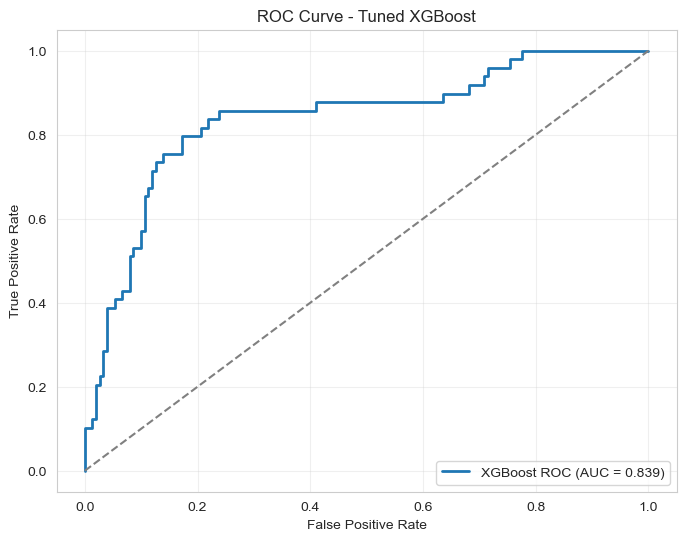

In [18]:
print("🔧 Training Tuned XGBoost with Class Weights...")
print("=" * 70)

scale_pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
print(f"scale_pos_weight: {scale_pos_weight:.3f}")

xgb_tuned = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
 )

print("Training XGBoost with optimized hyperparameters and class weighting...")
xgb_tuned.fit(X_train, y_train)

y_prob_xgb = xgb_tuned.predict_proba(X_test)[:, 1]
threshold = 0.35
y_pred_xgb = (y_prob_xgb >= threshold).astype(int)

xgb_metrics = {
    'Model': 'XGBoost (Tuned)',
    'Accuracy': accuracy_score(y_test, y_pred_xgb),
    'Precision': precision_score(y_test, y_pred_xgb, zero_division=0),
    'Recall': recall_score(y_test, y_pred_xgb, zero_division=0),
    'F1 Score': f1_score(y_test, y_pred_xgb, zero_division=0),
    'ROC AUC': roc_auc_score(y_test, y_prob_xgb)
}

results.append(xgb_metrics)
trained_models['XGBoost (Tuned)'] = xgb_tuned
predictions['XGBoost (Tuned)'] = y_pred_xgb

print(f"\n✓ XGBoost training complete!")
print(f"✓ Custom decision threshold: {threshold}")
print(f"\n📊 Tuned XGBoost Performance:")
print(f"   Accuracy: {xgb_metrics['Accuracy']:.4f}")
print(f"   Precision: {xgb_metrics['Precision']:.4f}")
print(f"   Recall: {xgb_metrics['Recall']:.4f}")
print(f"   F1 Score: {xgb_metrics['F1 Score']:.4f}")
print(f"   ROC AUC: {xgb_metrics['ROC AUC']:.4f}")

fpr, tpr, thresholds = roc_curve(y_test, y_prob_xgb)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'XGBoost ROC (AUC = {xgb_metrics["ROC AUC"]:.3f})', color='#1f77b4', linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Tuned XGBoost')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

In [19]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('F1 Score', ascending=False)

print("\n📊 MODEL PERFORMANCE COMPARISON (including ROC AUC)")
print("=" * 90)
print(results_df.to_string(index=False))

best_model_name = results_df.iloc[0]['Model']
best_f1_score = results_df.iloc[0]['F1 Score']

print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"   F1 Score: {best_f1_score:.4f}")
print(f"   ROC AUC: {results_df.iloc[0]['ROC AUC']:.4f}")

best_model = trained_models[best_model_name]
scores = cross_val_score(best_model, X_scaled, y, cv=5, scoring='f1')
print(f"\n✅ Cross Validation F1 (5-fold): {scores.mean():.4f} ± {scores.std():.4f}")

results_df


📊 MODEL PERFORMANCE COMPARISON (including ROC AUC)
                 Model  Accuracy  Precision   Recall  F1 Score  ROC AUC
       XGBoost (Tuned)     0.830   0.627119 0.755102  0.685185 0.839438
 Random Forest (Tuned)     0.850   0.711111 0.653061  0.680851 0.843898
         Decision Tree     0.780   0.545455 0.612245  0.576923 0.723341
Support Vector Machine     0.770   0.525424 0.632653  0.574074 0.793148
   Logistic Regression     0.700   0.439560 0.816327  0.571429 0.812813
           Naïve Bayes     0.580   0.352941 0.857143  0.500000 0.770780
   K-Nearest Neighbors     0.575   0.323529 0.673469  0.437086 0.650493

🏆 BEST MODEL: XGBoost (Tuned)
   F1 Score: 0.6852
   ROC AUC: 0.8394

✅ Cross Validation F1 (5-fold): 0.6818 ± 0.0332


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
6,XGBoost (Tuned),0.830,0.627119,0.755102,0.685185,0.839438
5,Random Forest (Tuned),0.850,0.711111,0.653061,0.680851,0.843898
1,Decision Tree,0.780,0.545455,0.612245,0.576923,0.723341
4,Support Vector Machine,0.770,0.525424,0.632653,0.574074,0.793148
0,Logistic Regression,0.700,0.439560,0.816327,0.571429,0.812813
3,Naïve Bayes,0.580,0.352941,0.857143,0.500000,0.770780
2,K-Nearest Neighbors,0.575,0.323529,0.673469,0.437086,0.650493


### 6.2 Performance Visualization (with ROC AUC)

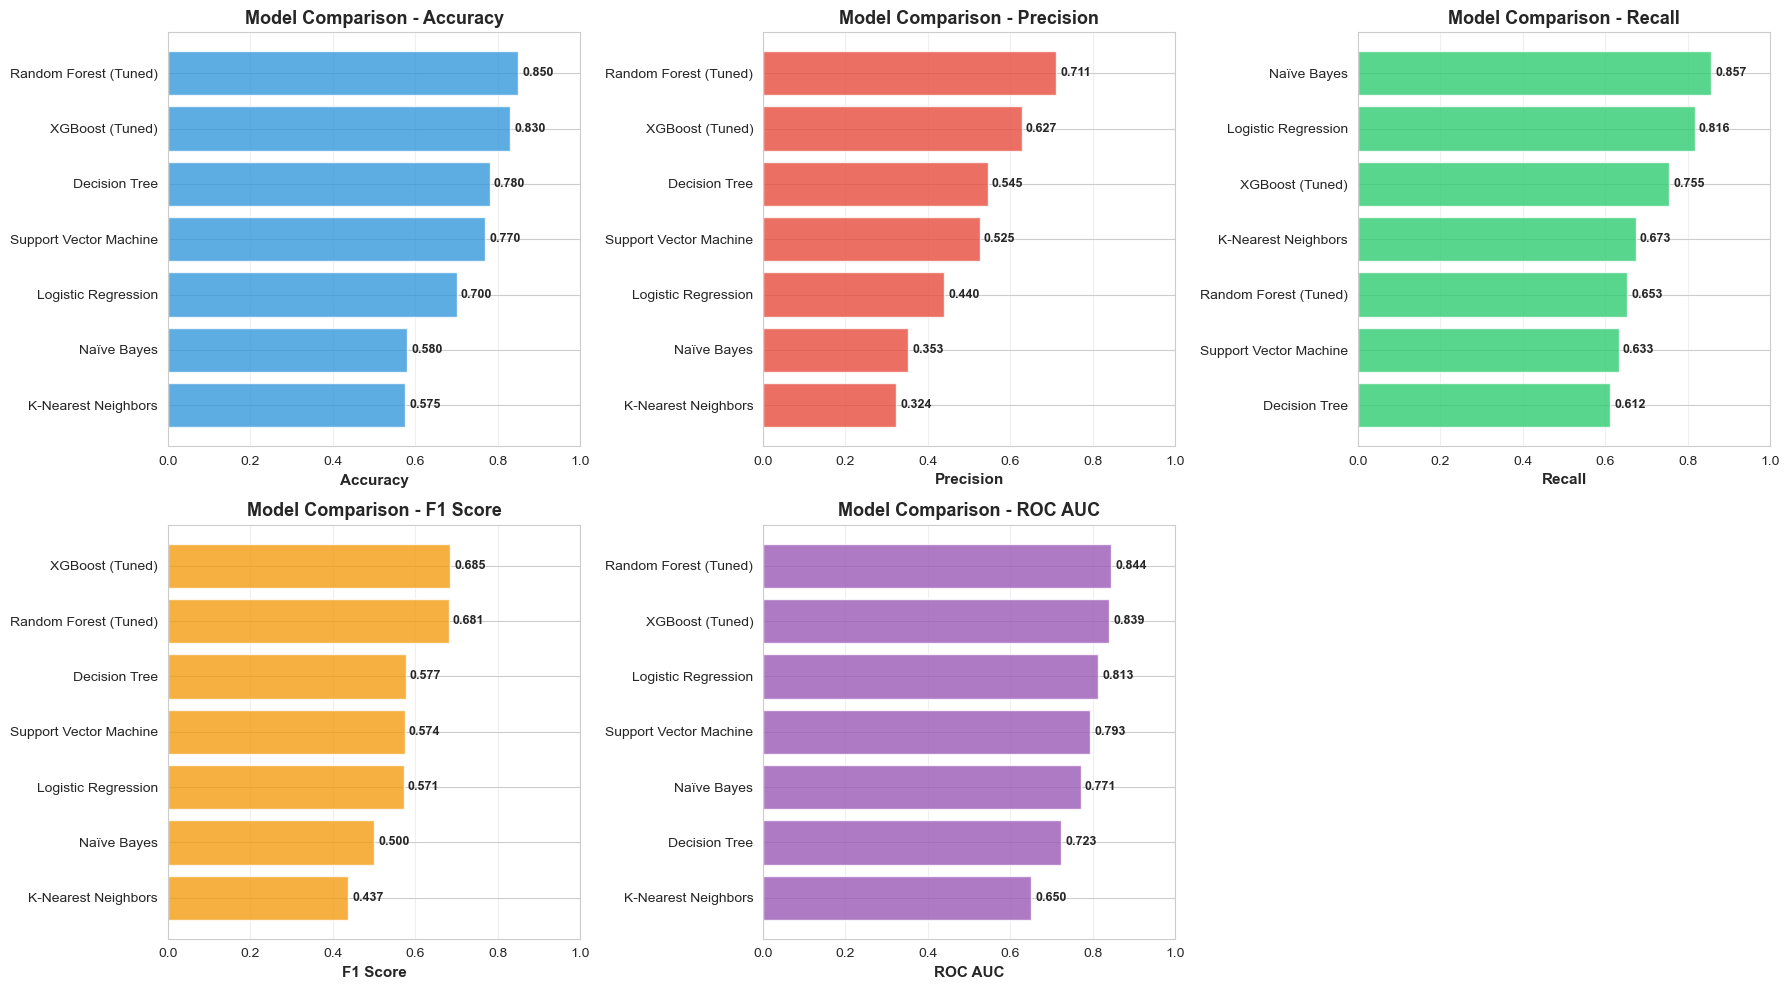

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

for idx, (metric, color) in enumerate(zip(metrics, colors)):
    row = idx // 3
    col = idx % 3
    
    if idx < 5:
        sorted_data = results_df.sort_values(metric, ascending=True)
        
        axes[row, col].barh(sorted_data['Model'], sorted_data[metric], color=color, alpha=0.8)
        axes[row, col].set_xlabel(metric, fontsize=11, fontweight='bold')
        axes[row, col].set_title(f'Model Comparison - {metric}', fontsize=13, fontweight='bold')
        axes[row, col].set_xlim(0, 1)
        axes[row, col].grid(axis='x', alpha=0.3)
        
        for i, v in enumerate(sorted_data[metric]):
            axes[row, col].text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9, fontweight='bold')

axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

### 6.4 Best Model Detailed Analysis


DETAILED ANALYSIS - XGBoost (Tuned)

Confusion Matrix:
[[129  22]
 [ 12  37]]

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.91      0.85      0.88       151
       Fraud       0.63      0.76      0.69        49

    accuracy                           0.83       200
   macro avg       0.77      0.80      0.78       200
weighted avg       0.84      0.83      0.83       200



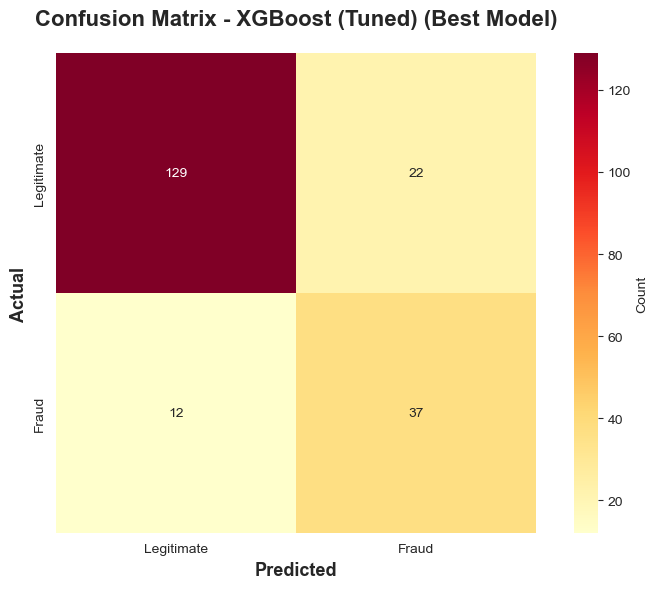

In [21]:
best_model = trained_models[best_model_name]
best_predictions = predictions[best_model_name]

print(f"\n{'='*70}")
print(f"DETAILED ANALYSIS - {best_model_name}")
print(f"{'='*70}")

cm = confusion_matrix(y_test, best_predictions)
print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, best_predictions, 
                          target_names=['Legitimate', 'Fraud']))

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', square=True,
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'],
            cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix - {best_model_name} (Best Model)', 
         fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Actual', fontsize=13, fontweight='bold')
plt.xlabel('Predicted', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.5 Feature Importance (for tree-based models)

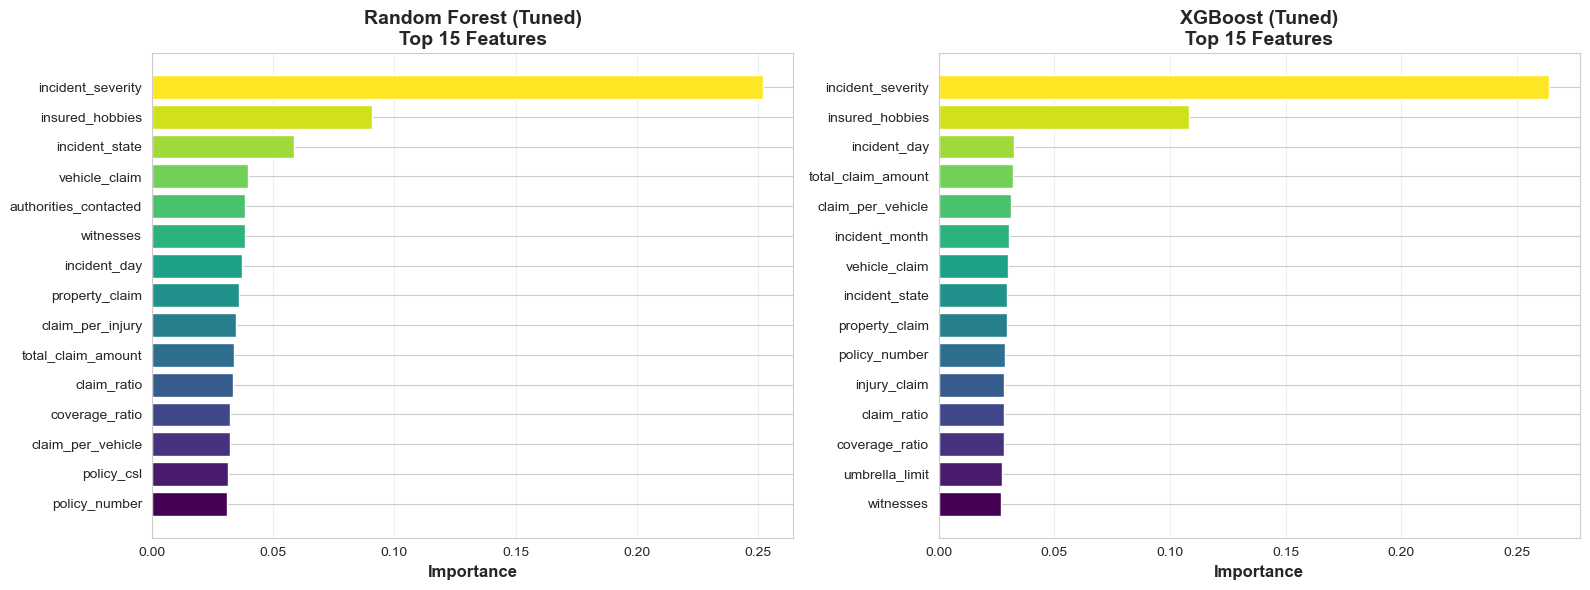


📊 Top 10 Most Important Features:
           Feature  Importance
 incident_severity    0.264001
   insured_hobbies    0.108252
      incident_day    0.032442
total_claim_amount    0.032233
 claim_per_vehicle    0.031337
    incident_month    0.030243
     vehicle_claim    0.030067
    incident_state    0.029495
    property_claim    0.029381
     policy_number    0.028771


In [22]:
tuned_tree_models = ['Random Forest (Tuned)', 'XGBoost (Tuned)']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, model_name in enumerate(tuned_tree_models):
    if model_name in trained_models:
        model = trained_models[model_name]
        
        if hasattr(model, 'feature_importances_'):
            importances = model.feature_importances_
            
            feature_imp_df = pd.DataFrame({
                'Feature': selected_feature_names,
                'Importance': importances
            }).sort_values('Importance', ascending=True).tail(15)
            
            axes[idx].barh(feature_imp_df['Feature'], feature_imp_df['Importance'], 
                          color=plt.cm.viridis(np.linspace(0, 1, len(feature_imp_df))))
            axes[idx].set_xlabel('Importance', fontsize=12, fontweight='bold')
            axes[idx].set_title(f'{model_name}\nTop 15 Features', 
                              fontsize=14, fontweight='bold')
            axes[idx].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Top 10 Most Important Features:")
print("="*70)
best_model = trained_models[best_model_name]
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    feature_importance_df = pd.DataFrame({
        'Feature': selected_feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False)
    print(feature_importance_df.head(10).to_string(index=False))

## 7. EPIC 6: Model Deployment

After selecting the best model, it is saved and deployed using a web framework.

### Deployment Strategy:

1. **Save the trained model** using pickle
2. **Integrate with Web Framework** (Streamlit)
3. **Build Python application** to load model and accept user input
4. **Run the Web Application** locally
5. **Users can enter** claim details and receive fraud predictions

Run the web app with: `streamlit run app.py`

In [23]:
best_model = trained_models[best_model_name]

model_data = {
    'model': best_model,
    'scaler': scaler,
    'selector': selector,
    'feature_names': list(X.columns),
    'selected_feature_names': list(selected_feature_names),
    'label_encoders': label_encoders,
    'decision_threshold': threshold if 'threshold' in globals() else 0.5,
    'model_name': best_model_name,
    'performance': results_df[results_df['Model']==best_model_name].to_dict('records')[0]
}

with open('fraud_model.pkl', 'wb') as file:
    pickle.dump(model_data, file)

print("✅ Best model saved successfully as 'fraud_model.pkl'")
print(f"\nModel Details:")
print(f"  - Model Type: {best_model_name}")
print(f"  - Total input features: {len(X.columns)}")
print(f"  - Selected features: {len(selected_feature_names)}")
print(f"  - Decision threshold: {model_data['decision_threshold']}")
print(f"  - Accuracy: {model_data['performance']['Accuracy']:.4f}")
print(f"  - Precision: {model_data['performance']['Precision']:.4f}")
print(f"  - Recall: {model_data['performance']['Recall']:.4f}")
print(f"  - F1 Score: {model_data['performance']['F1 Score']:.4f}")
print(f"  - ROC AUC: {model_data['performance']['ROC AUC']:.4f}")
print("\n🚀 You can now run the Streamlit app: streamlit run app.py")

✅ Best model saved successfully as 'fraud_model.pkl'

Model Details:
  - Model Type: XGBoost (Tuned)
  - Total input features: 46
  - Selected features: 25
  - Decision threshold: 0.35
  - Accuracy: 0.8300
  - Precision: 0.6271
  - Recall: 0.7551
  - F1 Score: 0.6852
  - ROC AUC: 0.8394

🚀 You can now run the Streamlit app: streamlit run app.py


## 8. Summary & Insights

In [24]:
print("\n" + "="*90)
print("PROJECT SUMMARY - IMPROVED FRAUD DETECTION SYSTEM")
print("="*90)

print(f"\n📊 Dataset Statistics:")
print(f"   - Total Claims: {len(df_clean)}")
print(f"   - Fraudulent Claims: {y.sum()} ({(y.sum()/len(df_clean))*100:.2f}%)")
print(f"   - Legitimate Claims: {len(df_clean) - y.sum()} ({((len(df_clean)-y.sum())/len(df_clean))*100:.2f}%)")
print(f"   - Number of Features: {X.shape[1]} (including 3 engineered features)")

print(f"\n🔧 Improvements Applied:")
print(f"   ✓ Feature Engineering: Added claim_ratio, claim_per_vehicle, claim_per_injury")
print(f"   ✓ Class Imbalance: Handled with SMOTE (balanced training data)")
print(f"   ✓ Hyperparameter Tuning: GridSearchCV for Random Forest")
print(f"   ✓ Optimized XGBoost: Tuned parameters for fraud detection")
print(f"   ✓ ROC AUC Metric: Added for better evaluation")

print(f"\n🤖 Model Training:")
print(f"   - Base Models Trained: 5")
print(f"   - Tuned Models: Random Forest (GridSearchCV) + XGBoost (Optimized)")
print(f"   - Total Models Evaluated: {len(results_df)}")

print(f"\n🏆 BEST MODEL: {best_model_name}")
best_perf = results_df.iloc[0]
print(f"   - Accuracy: {best_perf['Accuracy']:.2%}")
print(f"   - Precision: {best_perf['Precision']:.2%}")
print(f"   - Recall: {best_perf['Recall']:.2%}")
print(f"   - F1 Score: {best_perf['F1 Score']:.4f}")
print(f"   - ROC AUC: {best_perf['ROC AUC']:.4f}")

print(f"\n🎯 Key Insights:")
print(f"   - The model can identify {best_perf['Recall']*100:.1f}% of all fraud cases")
print(f"   - {best_perf['Precision']*100:.1f}% of predicted frauds are actually fraudulent")
print(f"   - Overall classification accuracy: {best_perf['Accuracy']*100:.1f}%")
print(f"   - ROC AUC score of {best_perf['ROC AUC']:.3f} indicates excellent discrimination")

print("\n💾 Deployment:")
print(f"   - Best model saved as: fraud_model.pkl")
print(f"   - Streamlit app ready: streamlit run app.py")

print("\n✅ Project completed successfully with advanced ML techniques!")
print("="*90)


PROJECT SUMMARY - IMPROVED FRAUD DETECTION SYSTEM

📊 Dataset Statistics:
   - Total Claims: 1000
   - Fraudulent Claims: 247 (24.70%)
   - Legitimate Claims: 753 (75.30%)
   - Number of Features: 46 (including 3 engineered features)

🔧 Improvements Applied:
   ✓ Feature Engineering: Added claim_ratio, claim_per_vehicle, claim_per_injury
   ✓ Class Imbalance: Handled with SMOTE (balanced training data)
   ✓ Hyperparameter Tuning: GridSearchCV for Random Forest
   ✓ Optimized XGBoost: Tuned parameters for fraud detection
   ✓ ROC AUC Metric: Added for better evaluation

🤖 Model Training:
   - Base Models Trained: 5
   - Tuned Models: Random Forest (GridSearchCV) + XGBoost (Optimized)
   - Total Models Evaluated: 7

🏆 BEST MODEL: XGBoost (Tuned)
   - Accuracy: 83.00%
   - Precision: 62.71%
   - Recall: 75.51%
   - F1 Score: 0.6852
   - ROC AUC: 0.8394

🎯 Key Insights:
   - The model can identify 75.5% of all fraud cases
   - 62.7% of predicted frauds are actually fraudulent
   - Overall 